In [2]:
import pandas as pd

# ==========================================
# STEP 0: DATA LOADING (The Missing Part)
# We must read the CSV files into memory first
# ==========================================
print("Loading datasets...")

utenti = pd.read_csv('utenti_reduced.csv')
accessi = pd.read_csv('accessi_reduced.csv')
codici = pd.read_csv('codici_reduced.csv')
missions = pd.read_csv('missioni_reduced.csv')
rewards = pd.read_csv('premi_reduced.csv')
rewusers = pd.read_csv('rewusers_reduced.csv')

print("Files loaded successfully!")

# ==========================================
# STEP 1: ID STANDARDIZATION
# Cleaning spaces and converting to lowercase for consistent merging
# ==========================================
def clean_id(df, col):
    df[col] = df[col].astype(str).str.strip().str.lower()

# Apply cleaning to all relevant ID columns
for d, c in [(utenti, 'idSSO'), (accessi, 'idsso'), (codici, 'userId'), 
             (missions, 'userId'), (rewards, 'userid'), (rewusers, 'idSSO'), (rewusers, 'userId')]:
    clean_id(d, c)

# ==========================================
# STEP 2: CREATING THE BRIDGE
# Mapping idSSO to userId using the rewusers file
# ==========================================
user_map = utenti[['idSSO']].merge(rewusers[['idSSO', 'userId']], on='idSSO', how='left')

# ==========================================
# STEP 3: BEHAVIORAL AGGREGATION
# Grouping data by user to get totals
# ==========================================

# Aggregate Purchase Data
codici_agg = codici.groupby('userId').agg(
    total_points=('points', 'sum'),
    total_codes=('code', 'count'),
    last_scan_date=('date_created_at', 'max')
).reset_index()

# Aggregate App Login Data
accessi_agg = accessi.groupby('idsso').agg(
    total_logins=('created_at', 'count'),
    last_login_date=('created_at', 'max')
).reset_index()

# Aggregate Missions Data
missions_agg = missions.groupby('userId').agg(
    total_missions=('missionDetailId', 'count')
).reset_index()

# ==========================================
# STEP 4: MASTER MERGE
# Combining everything into the final dataframe: df_final
# ==========================================
df_final = user_map.copy()
df_final = df_final.merge(codici_agg, on='userId', how='left')
df_final = df_final.merge(missions_agg, on='userId', how='left')
df_final = df_final.merge(utenti, on='idSSO', how='left')
df_final = df_final.merge(accessi_agg, left_on='idSSO', right_on='idsso', how='left')

# ==========================================
# STEP 5: FINAL DATA CLEANING
# Filling missing values with 0 for behavioral columns
# ==========================================
behavior_cols = ['total_points', 'total_codes', 'total_logins', 'total_missions']
df_final[behavior_cols] = df_final[behavior_cols].fillna(0)
df_final.drop(columns=['idsso'], inplace=True, errors='ignore')

print("--- DATA INTEGRATION COMPLETE ---")
print(f"Total Unique Users: {len(df_final)}")

# Preview the result
df_final[['idSSO', 'total_codes', 'last_scan_date']].dropna(subset=['last_scan_date']).head()

Loading datasets...
Files loaded successfully!
--- DATA INTEGRATION COMPLETE ---
Total Unique Users: 6205


,idSSO,total_codes,last_scan_date
0,4f12b21d8e9c49d1a4085f21f2d9d5ec708791b341ca25...,56.0,2025-01-31
1,acf181fcd82a7451e37f3c33ac7008cb1906d4f0167717...,11.0,2024-09-22
2,e12fc19c9fafbb21c93bf76872f5caf55a3c87eec59116...,90.0,2025-10-01
3,62af6798bfe954edde440987878020282525e18193069b...,8.0,2025-10-05
4,1a5374b9d0a8a05eda3e1fd71659fd64b9b82cce72f394...,99.0,2025-09-10


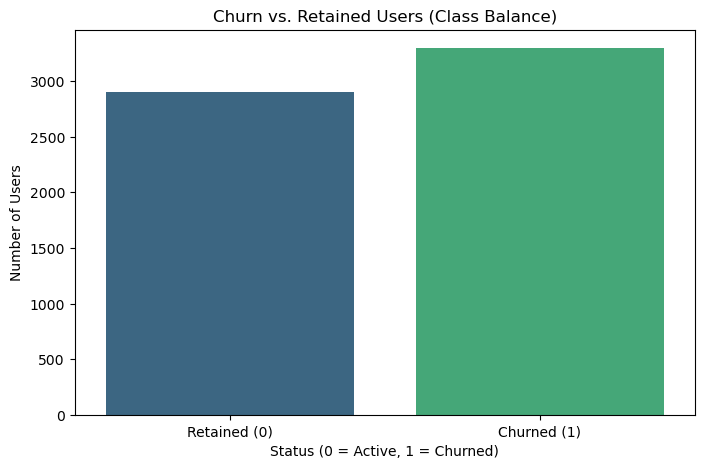

--- Class Distribution (%) ---
is_churn
1    53.150685
0    46.849315
Name: proportion, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

df_final['last_scan_date'] = pd.to_datetime(df_final['last_scan_date'])
df_final['DtaRegUserData'] = pd.to_datetime(df_final['DtaRegUserData'])

df_final['last_login_date'] = pd.to_datetime(df_final['last_login_date'])
snapshot_date = df_final['last_login_date'].max()
df_final['days_since_last_login'] = (snapshot_date - df_final['last_login_date']).dt.days
df_final['days_since_last_login'] = df_final['days_since_last_login'].fillna(999)
df_final['is_churn'] = (df_final['days_since_last_login'] > 90).astype(int)

df_final['tenure_days'] = (snapshot_date - df_final['DtaRegUserData']).dt.days
df_final['tenure_days'] = df_final['tenure_days'].fillna(df_final['tenure_days'].median())


df_final['points_per_code'] = df_final['total_points'] / (df_final['total_codes'] + 1)

plt.figure(figsize=(8, 5))
sns.countplot(x='is_churn', data=df_final, hue='is_churn', palette='viridis', legend=False)
plt.title('Churn vs. Retained Users (Class Balance)')
plt.xticks([0, 1], ['Retained (0)', 'Churned (1)'])
plt.xlabel('Status (0 = Active, 1 = Churned)')
plt.ylabel('Number of Users')
plt.show()

print("--- Class Distribution (%) ---")
print(df_final['is_churn'].value_counts(normalize=True) * 100)

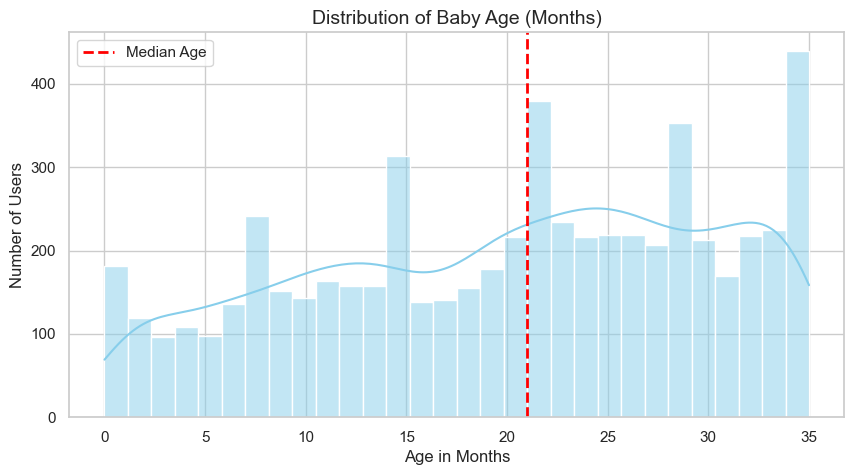

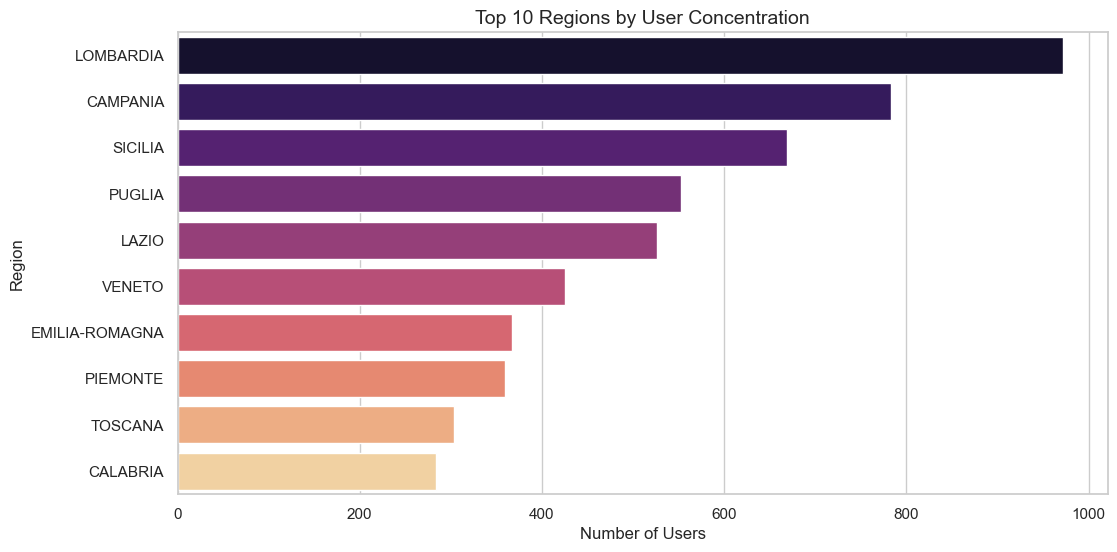

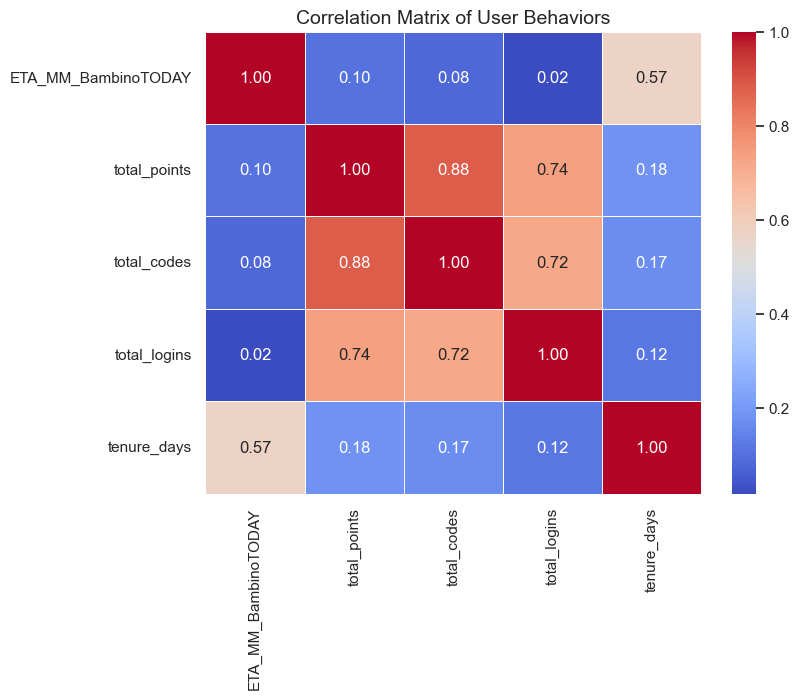

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

# ==========================================
# GRAPH 1: Baby Age Distribution
# Shows the demographic of the app's core users
# ==========================================
plt.figure(figsize=(10, 5))
# Filtering out weird negative ages or extreme outliers if any exist
valid_ages = df_final[(df_final['ETA_MM_BambinoTODAY'] >= 0) & (df_final['ETA_MM_BambinoTODAY'] <= 60)]
sns.histplot(valid_ages['ETA_MM_BambinoTODAY'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Baby Age (Months)', fontsize=14)
plt.xlabel('Age in Months')
plt.ylabel('Number of Users')
plt.axvline(valid_ages['ETA_MM_BambinoTODAY'].median(), color='red', linestyle='dashed', linewidth=2, label='Median Age')
plt.legend()
plt.show()

# ==========================================
# GRAPH 2: Top 10 Regions by User Count
# Geographic distribution for marketing focus
# ==========================================
plt.figure(figsize=(12, 6))
top_regions = df_final['Regione'].value_counts().head(10)
sns.barplot(x=top_regions.values, y=top_regions.index, palette='magma', hue=top_regions.index, legend=False)
plt.title('Top 10 Regions by User Concentration', fontsize=14)
plt.xlabel('Number of Users')
plt.ylabel('Region')
plt.show()

# ==========================================
# GRAPH 3: Correlation Heatmap
# Finding relationships between numerical behaviors before ML
# ==========================================
plt.figure(figsize=(8, 6))
corr_features = ['ETA_MM_BambinoTODAY', 'total_points', 'total_codes', 'total_logins', 'tenure_days']
# Calculate correlation matrix
corr_matrix = df_final[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of User Behaviors', fontsize=14)
plt.show()


--- Model Accuracy: 0.91 ---
--- ROC-AUC Score:  0.970 ---

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       586
           1       0.92      0.91      0.91       655

    accuracy                           0.91      1241
   macro avg       0.91      0.91      0.91      1241
weighted avg       0.91      0.91      0.91      1241


--- Cross-Validation ROC-AUC: 0.971 (+/- 0.004) ---


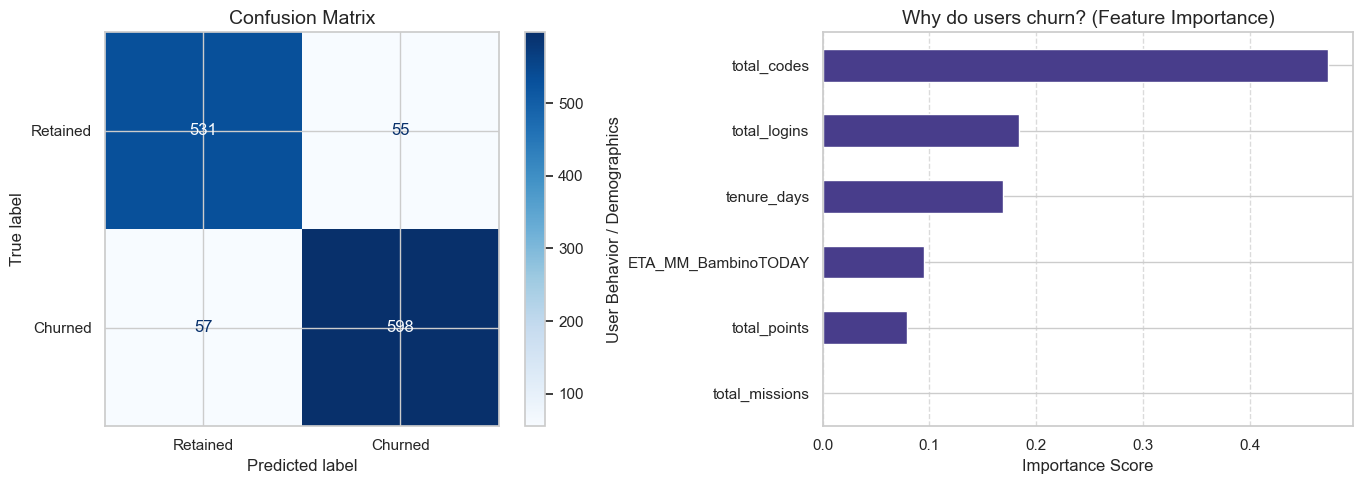

In [5]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, ConfusionMatrixDisplay)
import numpy as np


features = [
    'ETA_MM_BambinoTODAY', 'total_points', 'total_codes',
    'total_logins', 'total_missions', 'tenure_days'
]

df_final['ETA_MM_BambinoTODAY'] = df_final['ETA_MM_BambinoTODAY'].fillna(df_final['ETA_MM_BambinoTODAY'].median())

X = df_final[features]
y = df_final['is_churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"\n--- Model Accuracy: {accuracy_score(y_test, y_pred):.2f} ---")
print(f"--- ROC-AUC Score:  {roc_auc_score(y_test, y_proba):.3f} ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"\n--- Cross-Validation ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f}) ---")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Retained', 'Churned'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=14)

# Feature Importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='darkslateblue', ax=axes[1])
axes[1].set_title('Why do users churn? (Feature Importance)', fontsize=14)
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('User Behavior / Demographics')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [6]:
df_final['CAP'] = (
    df_final['CAP']
    .astype(str)
    .str.replace('\.0', '', regex=True)
    .str.strip()
    .replace(['nan', 'None', '', 'NaN'], 'Unknown')
)



In [11]:
df_final['churn_probability'] = (model.predict_proba(df_final[features].fillna(0))[:, 1] * 100).round(0).astype(int)

def assign_segment(row):
    if row['is_churn'] == 1:
        if row['total_logins'] == 0:
            return 'High Risk'
        else:
            return 'Medium Risk'
    else:
        return 'Loyal'

df_final['segment'] = df_final.apply(assign_segment, axis=1)

df_final['ETA_MM_BambinoTODAY'] = pd.to_numeric(df_final['ETA_MM_BambinoTODAY'], errors='coerce')

df_final['baby_age_group'] = pd.cut(
    df_final['ETA_MM_BambinoTODAY'],
    bins=[0, 6, 12, 24, 36, 999],
    labels=['0-6m', '6-12m', '12-24m', '24-36m', '36m+']
).astype(str)

df_final['CAP'] = (
    df_final['CAP']
    .astype(str)
    .str.replace('\.0', '', regex=True)
    .str.strip()
    .replace(['nan', 'None', '', 'NaN'], 'Unknown')
)

df_final = df_final.loc[:, ~df_final.columns.str.contains('^Unnamed')]

df_final.to_csv('fater_final_results.csv', index=False)
print(df_final[['segment', 'baby_age_group', 'churn_probability']].head())
print("CSV ready!")

       segment baby_age_group  churn_probability
0  Medium Risk         12-24m                 37
1  Medium Risk         12-24m                 52
2        Loyal         12-24m                  1
3        Loyal            nan                  0
4        Loyal         24-36m                 33
CSV ready!
